# 04: Attendance Model: Adding Transit Accessibility

Team-season attendance regression (`log(attendance) ~ ppg + market_size_log + new_stadium_flag + rivalry_flag +
dist_miles`) with transit-accessibility features, aggregated from
`data/processed/games_with_transit.csv` (vendored from `nwsl_transportation`) to team-season level.

**Approach:** add accessibility in with `catchment_pop_60min` (population reachable within a
60-min transit+walk trip of the stadium) plus a `has_rail_access` flag (subway/rail presence,
vs. bus-only), testing whether *heavy rail specifically* matters, not just stop density. Checks
collinearity with `dist_miles` first, since downtown-adjacent stadiums are usually rail-adjacent
too, and the panel is small (~90 team-seasons).

**Note (2026-08-23):** the transit-accessibility predictor here used to be `nearest_stop_distance_mi`
(vendored wholesale from `nwsl_transportation`'s OSM/Overpass pull, in `games_with_transit.csv`).
Switched to `catchment_pop_60min` -- this project's own r5py-isochrone-derived accessibility
measure (built in `06`/`10`, computed in `11_catboost_feature_engineering.ipynb`) -- so this
notebook's transit feature is the same one CatBoost (`11`/`12`) uses as `metro_size`, instead of
two different, uncoordinated accessibility measures across the two models. That measure isn't
written to any shared data file, only to `output/venue_catchment_population.csv`, so **this
notebook now has to run after `11`** (an exception to the usual 01-13 run order, called out here
rather than silently).

**Note (2026-08-23, cont.):** `catchment_pop_60min_100k` turned out to correlate 0.70 with
`market_size_log` (the baseline model's hand-typed metro-population predictor) -- both are
proxies for "how big/reachable is this market," just built through very different pipelines
(hand-typed Census lookup vs. this project's own isochrone computation). That collinearity was
distorting `market_size_log`'s coefficient in the **extended** spec (flipping its sign vs. the
baseline). Dropped `market_size_log` from the extended predictor set only -- the baseline spec
keeps it, unchanged, so it still matches `nwsl-project`'s `03_stadiums_analyze.ipynb` baseline
exactly for the apples-to-apples comparison.

**Note (2026-08-23, cont. 2):** `dist_miles` is also dropped from the extended spec (kept in the
baseline, same reasoning as `market_size_log`) -- its coefficient was tiny and unstable in sign
across specs (-0.0061 baseline, +0.0019 with `market_size_log` still present), not carrying real
signal once `catchment_pop_60min_100k` is in the model. The collinearity check below (originally
run to see if `dist_miles` and the transit feature were redundant) is now diagnostic context only,
not a gate on the extended model's predictor list.

**Inputs:** `nwsl-project/data/processed/{stadiums,teams_clean,games_clean}.csv`,
`data/processed/games_with_transit.csv` (vendored from `nwsl_transportation`),
`output/venue_catchment_population.csv` (written by `11_catboost_feature_engineering.ipynb` --
run that notebook first)
**Outputs:** `output/attendance_model_with_transit.txt`,
`output/nwsl_attendance_transit_coefficients.png`, `output/nwsl_gotham_groupkfold_check.png`,
`output/nwsl_transit_collinearity_check.png`, `output/nwsl_attendance_shap_summary.png`,
`output/nwsl_attendance_shap_dependence_transit.png`


In [1]:
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, r2_score, mean_squared_error

DATA_PROCESSED_DIR = os.path.join("..", "data", "processed")
OUTPUT_DIR = os.path.join("..", "output")
os.makedirs(OUTPUT_DIR, exist_ok=True)

NWSL_PROJECT_PROCESSED = os.path.join("..", "..", "..", "QSS 20", "nwsl-project", "data", "processed")

## Rebuild the baseline team-season panel


In [2]:
stadiums = pd.read_csv(os.path.join(NWSL_PROJECT_PROCESSED, "stadiums.csv"))
teams = pd.read_csv(os.path.join(NWSL_PROJECT_PROCESSED, "teams_clean.csv"))
games = pd.read_csv(os.path.join(NWSL_PROJECT_PROCESSED, "games_clean.csv"))

# COVID exclusion: 2020 and 2021 because of little to no attendance
COVID_SEASONS = [2020, 2021]

nwsl_teams = teams[(teams["league"] == "nwsl") & (teams["year_of_death"].isna())]
nwsl_games = games[games["league"] == "nwsl"].dropna(subset=["attendance"])
nwsl_games = nwsl_games[nwsl_games["attendance"] > 0]
nwsl_games = nwsl_games[~nwsl_games["season_name"].isin(COVID_SEASONS)]

# Team-season average attendance + points-per-game (regular season, home games for attendance)
home_att = nwsl_games[nwsl_games["knockout_game"] == False].groupby(
    ["home_team_id", "season_name"]
)["attendance"].mean().reset_index().rename(columns={"home_team_id": "team_id", "attendance": "attendance"})

regular_season = nwsl_games[nwsl_games["knockout_game"] == False].dropna(subset=["home_score", "away_score"])
home_results = regular_season[["season_name", "home_team_id", "home_score", "away_score"]].rename(
    columns={"home_team_id": "team_id", "home_score": "gf", "away_score": "ga"}
)
away_results = regular_season[["season_name", "away_team_id", "away_score", "home_score"]].rename(
    columns={"away_team_id": "team_id", "away_score": "gf", "home_score": "ga"}
)
results = pd.concat([home_results, away_results])
results["points"] = np.select([results["gf"] > results["ga"], results["gf"] == results["ga"]], [3, 1], default=0)
ppg = results.groupby(["team_id", "season_name"]).apply(
    lambda d: d["points"].sum() / len(d), include_groups=False
).reset_index(name="ppg")

reg_df = home_att.merge(ppg, on=["team_id", "season_name"])
reg_df = reg_df.merge(teams[["team_id", "team_name"]], on="team_id")
print(f"{len(reg_df)} team-seasons (2020-2021 excluded)")
reg_df.head()


106 team-seasons (2020-2021 excluded)


,team_id,season_name,attendance,ppg,team_name
0,2lqRn34qr0,2026,19577.000000,1.263158,Denver Summit FC
1,315VnJ759x,2024,13671.083333,1.360000,Bay FC
2,315VnJ759x,2025,14822.692308,0.769231,Bay FC
3,315VnJ759x,2026,11731.222222,1.000000,Bay FC
4,4JMAk47qKg,2016,5726.300000,1.100000,Houston Dash


In [3]:
# Table generated with AI, validated manually
METRO_POPULATION_MILLIONS = {
    "Orlando Pride": 2.7, "NJ/NY Gotham FC": 19.5, "Houston Dash": 7.3, "Washington Spirit": 6.3,
    "Seattle Reign FC": 4.0, "Chicago Stars FC": 9.4, "Portland Thorns FC": 2.5,
    "North Carolina Courage": 1.5, "Utah Royals FC": 1.26, "Kansas City Current": 2.19,
    "Racing Louisville FC": 1.37, "San Diego Wave FC": 3.3, "Angel City FC": 13.0, "Bay FC": 9.0,
    "Boston Legacy FC": 4.9, "Denver Summit FC": 2.98,
}
reg_df["market_size_log"] = reg_df["team_name"].map(lambda t: np.log10(METRO_POPULATION_MILLIONS.get(t, np.nan)))

CITY_CENTER = {
    "Houston Dash": (29.7604, -95.3698), "Seattle Reign FC": (47.6062, -122.3321),
    "Chicago Stars FC": (41.8781, -87.6298), "Portland Thorns FC": (45.5152, -122.6784),
    "Orlando Pride": (28.5384, -81.3789), "Washington Spirit": (38.9072, -77.0369),
    "NJ/NY Gotham FC": (40.7128, -74.0060), "North Carolina Courage": (35.7796, -78.6382),
    "Utah Royals FC": (40.7608, -111.8910), "Kansas City Current": (39.0997, -94.5786),
    "Racing Louisville FC": (38.2527, -85.7585), "San Diego Wave FC": (32.7157, -117.1611),
    "Angel City FC": (34.0522, -118.2437), "Bay FC": (37.3382, -121.8863),
}
STADIUM_COORDS = [
    ("Houston Dash", 2016, 2026, 29.7522, -95.3524),
    ("Seattle Reign FC", 2016, 2018, 47.6187, -122.3212),
    ("Seattle Reign FC", 2019, 2021, 47.2383, -122.4976),
    ("Seattle Reign FC", 2022, 2026, 47.5952, -122.3316),
    ("Chicago Stars FC", 2016, 2025, 41.7647, -87.8061),
    ("Portland Thorns FC", 2016, 2026, 45.5214, -122.6917),
    ("Orlando Pride", 2016, 2016, 28.5389, -81.4028),
    ("Orlando Pride", 2017, 2026, 28.5411, -81.3893),
    ("Washington Spirit", 2016, 2019, 39.1528, -77.3136),
    ("Washington Spirit", 2021, 2026, 38.8683, -77.0122),
    ("NJ/NY Gotham FC", 2016, 2019, 40.5185, -74.4637),
    ("NJ/NY Gotham FC", 2021, 2026, 40.7367, -74.1503),
    ("North Carolina Courage", 2017, 2026, 35.7869, -78.7550),
    ("Utah Royals FC", 2018, 2026, 40.5829, -111.8932),
    ("Kansas City Current", 2022, 2023, 39.1214, -94.8210),
    ("Kansas City Current", 2024, 2026, 39.1194, -94.5666),
    ("Racing Louisville FC", 2021, 2026, 38.2503, -85.7034),
    ("San Diego Wave FC", 2022, 2022, 32.7972, -117.1708),
    ("San Diego Wave FC", 2023, 2026, 32.7842, -117.1224),
    ("Angel City FC", 2022, 2026, 34.0130, -118.2850),
    ("Bay FC", 2024, 2026, 37.3514, -121.9250),
]

STADIUM_MOVES = {
    "Kansas City Current": 2024, "San Diego Wave FC": 2023, "Seattle Reign FC": 2022,
    "Washington Spirit": 2021, "NJ/NY Gotham FC": 2021,
}

# Calculates distance with lat/lon
def haversine_miles(lat1, lon1, lat2, lon2):
    R = 3958.8
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat, dlon = lat2 - lat1, lon2 - lon1
    a = np.sin(dlat / 2) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2) ** 2
    return 2 * R * np.arcsin(np.sqrt(a))


def lookup_stadium_coords(team, season):
    for t, y0, y1, lat, lon in STADIUM_COORDS:
        if t == team and y0 <= season <= y1:
            return lat, lon
    return np.nan, np.nan


stad_coords = reg_df.apply(lambda r: lookup_stadium_coords(r["team_name"], r["season_name"]), axis=1)
reg_df["stad_lat"] = [c[0] for c in stad_coords]
reg_df["stad_lon"] = [c[1] for c in stad_coords]
reg_df["center_lat"] = reg_df["team_name"].map(lambda t: CITY_CENTER.get(t, (np.nan, np.nan))[0])
reg_df["center_lon"] = reg_df["team_name"].map(lambda t: CITY_CENTER.get(t, (np.nan, np.nan))[1])
reg_df["dist_miles"] = haversine_miles(reg_df["stad_lat"], reg_df["stad_lon"], reg_df["center_lat"], reg_df["center_lon"])
reg_df["new_stadium_flag"] = reg_df.apply(
    lambda r: int(r["team_name"] in STADIUM_MOVES and r["season_name"] >= STADIUM_MOVES[r["team_name"]]), axis=1
)
reg_df["rivalry_flag"] = reg_df["team_name"].isin(["Portland Thorns FC", "Seattle Reign FC"]).astype(int)

reg_df = reg_df.dropna(subset=["dist_miles", "market_size_log"]).reset_index(drop=True)
reg_df["log_attendance"] = np.log(reg_df["attendance"])
print(f"{len(reg_df)} team-seasons after dropping missing dist_miles/market_size_log")


98 team-seasons after dropping missing dist_miles/market_size_log


## Add transit accessibility, aggregated to team-season

`games_with_transit.csv` is game-level; aggregate to (team_id, season) by averaging over a
team's *home* games that season (accessibility is tied to the stadium they played in, so this
should be near-constant within a team-season except for the rare mid-season venue change).
`catchment_pop_60min` comes from a separate file (`output/venue_catchment_population.csv`,
written by `11`), joined in on `stadium_id`.


In [4]:
transit_games = pd.read_csv(os.path.join(DATA_PROCESSED_DIR, "games_with_transit.csv"))
transit_games = transit_games[transit_games["league"] == "nwsl"]

transit_games["has_rail_access"] = (
    (transit_games["stops_subway"].fillna(0) > 0) | (transit_games["stops_rail"].fillna(0) > 0)
).astype(int)

team_season_transit = transit_games.groupby(["home_team_id", "season_name"]).agg(
    has_rail_access=("has_rail_access", "max"),  # any home game at a rail-served stadium that season
    stop_count_catchment=("stop_count_catchment", "mean"),
    stadium_id=("stadium_id", "first"),  # constant within a team-season except rare mid-season moves
).reset_index().rename(columns={"home_team_id": "team_id"})

reg_df = reg_df.merge(team_season_transit, on=["team_id", "season_name"], how="left")

# catchment_pop_60min: this project's own r5py-isochrone accessibility measure (same one CatBoost
# calls metro_size in 11/12), not part of games_with_transit.csv -- written separately by 11 to
# output/venue_catchment_population.csv precisely so downstream notebooks don't hardcode it.
# Rescaled to per-100k reachable population -- raw catchment_pop_60min is in the hundreds of
# thousands, which makes its LinearRegression coefficient round to 0.0000 (a 1-person increase
# is not a meaningful unit), the same reason market_size_log above is transformed rather than
# used as raw population.
catchment = pd.read_csv(os.path.join(OUTPUT_DIR, "venue_catchment_population.csv"))
catchment["catchment_pop_60min_100k"] = catchment["catchment_pop_60min"] / 100_000
reg_df = reg_df.merge(catchment[["stadium_id", "catchment_pop_60min_100k"]], on="stadium_id", how="left")

print(f"Transit features matched for {reg_df['catchment_pop_60min_100k'].notna().sum()} / {len(reg_df)} team-seasons")
reg_df[["team_name", "season_name", "dist_miles", "catchment_pop_60min_100k", "has_rail_access"]].head(10)


Transit features matched for 82 / 98 team-seasons


,team_name,season_name,dist_miles,catchment_pop_60min_100k,has_rail_access
0,Bay FC,2024,2.313173,4.71028,0
1,Bay FC,2025,2.313173,4.71028,0
2,Bay FC,2026,2.313173,4.71028,0
3,Houston Dash,2016,1.187579,5.49316,0
4,Houston Dash,2017,1.187579,5.49316,0
5,Houston Dash,2018,1.187579,5.49316,0
6,Houston Dash,2019,1.187579,5.49316,0
7,Houston Dash,2022,1.187579,5.49316,0
8,Houston Dash,2023,1.187579,5.49316,0
9,Houston Dash,2024,1.187579,5.49316,0


## Collinearity check before adding to the model

If `catchment_pop_60min_100k` is highly correlated with `dist_miles`, adding both would just
inflate standard errors on a panel this small (~90 team-seasons) without adding real signal.


82 team-seasons with transit data for the extended model
                          dist_miles  catchment_pop_60min_100k  \
dist_miles                      1.00                     -0.35   
catchment_pop_60min_100k       -0.35                      1.00   
has_rail_access                -0.05                      0.44   
market_size_log                -0.01                      0.70   

                          has_rail_access  market_size_log  
dist_miles                          -0.05            -0.01  
catchment_pop_60min_100k             0.44             0.70  
has_rail_access                      1.00             0.40  
market_size_log                      0.40             1.00  


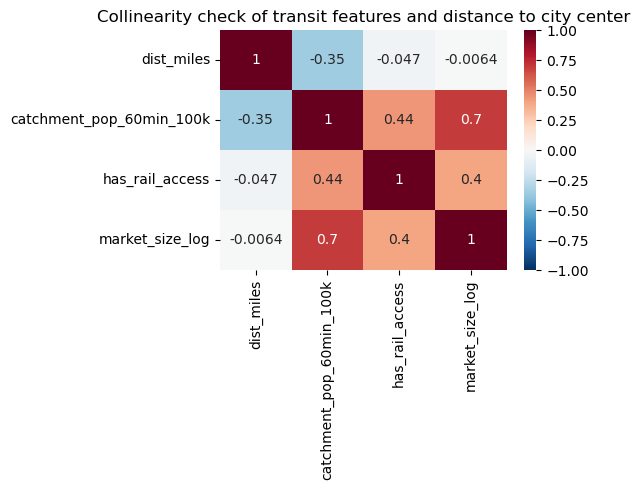

In [5]:
transit_reg_df = reg_df.dropna(subset=["catchment_pop_60min_100k"]).reset_index(drop=True)
print(f"{len(transit_reg_df)} team-seasons with transit data for the extended model")

corr_check = transit_reg_df[["dist_miles", "catchment_pop_60min_100k", "has_rail_access", "market_size_log"]].corr()
print(corr_check.round(2))

plt.figure(figsize=(6, 5))
sns.heatmap(corr_check, annot=True, cmap="RdBu_r", center=0, vmin=-1, vmax=1)
plt.title("Collinearity check of transit features and distance to city center")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "nwsl_transit_collinearity_check.png"), dpi=150)
plt.show()


### `has_rail_access` is unreliable -> dropped

has_rail_access=1` for only 3 teams in the whole panel (Boston Legacy FC, a brand-new
2026 expansion team with just 1 season and no track record yet, NJ/NY Gotham FC post-2021 Red
Bull Arena, and Seattle Reign post-2022 Lumen Field). 

In [6]:
rail_team_seasons = transit_reg_df[transit_reg_df["has_rail_access"] == 1][["team_name", "season_name"]]
print(f"has_rail_access=1 for {len(rail_team_seasons)} / {len(transit_reg_df)} team-seasons, "
      f"spanning {rail_team_seasons['team_name'].nunique()} teams:")
print(rail_team_seasons.to_string(index=False))


has_rail_access=1 for 10 / 82 team-seasons, spanning 2 teams:
       team_name  season_name
Seattle Reign FC         2022
Seattle Reign FC         2023
Seattle Reign FC         2024
Seattle Reign FC         2025
Seattle Reign FC         2026
 NJ/NY Gotham FC         2022
 NJ/NY Gotham FC         2023
 NJ/NY Gotham FC         2024
 NJ/NY Gotham FC         2025
 NJ/NY Gotham FC         2026


## Extended regression: baseline predictors + transit accessibility

Same linear-regression-on-`log(attendance)` setup as `03_stadiums_analyze.ipynb`, same 80/20
split and random state, extended with `catchment_pop_60min_100k`.


In [7]:
baseline_predictors = ["ppg", "market_size_log", "new_stadium_flag", "rivalry_flag", "dist_miles"]
# market_size_log and dist_miles both dropped from the extended spec: market_size_log correlates
# 0.70 with catchment_pop_60min_100k (see collinearity check above), and dist_miles's coefficient
# was tiny and unstable in sign across specs -- neither carries real signal once
# catchment_pop_60min_100k is in the model.
transit_predictors = ["ppg", "new_stadium_flag", "rivalry_flag", "catchment_pop_60min_100k"]

def fit_and_report(df, predictors, label):
    X = df[predictors]
    y = df["log_attendance"]
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    model = LinearRegression().fit(X_train, y_train)
    y_pred = model.predict(X_test)
    test_r2 = r2_score(y_test, y_pred)
    test_rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    print(f"=== {label} (n={len(df)}) ===")
    for name, coef in zip(predictors, model.coef_):
        print(f"  {name:>24}: {coef:+.4f}  (~{(np.exp(coef) - 1) * 100:+.2f}%)")
    print(f"  Train R2: {model.score(X_train, y_train):.3f}  |  Test R2: {test_r2:.3f}  |  Test RMSE: {test_rmse:.3f}\n")
    return model

baseline_model = fit_and_report(transit_reg_df, baseline_predictors, "Baseline (same team-seasons, for apples-to-apples comparison)")
transit_model = fit_and_report(transit_reg_df, transit_predictors, "Extended with transit accessibility (catchment_pop_60min_100k; market_size_log, dist_miles dropped)")

with open(os.path.join(OUTPUT_DIR, "attendance_model_with_transit.txt"), "w") as f:
    f.write("Baseline predictors: " + ", ".join(baseline_predictors) + "\n")
    for name, coef in zip(baseline_predictors, baseline_model.coef_):
        f.write(f"  {name:>24}: {coef:+.4f}\n")
    f.write("\nExtended predictors: " + ", ".join(transit_predictors) + "\n")
    for name, coef in zip(transit_predictors, transit_model.coef_):
        f.write(f"  {name:>24}: {coef:+.4f}\n")
    f.write("\nNote: has_rail_access was tested but excluded from this final spec -- "
            "it's 1 for only 3 teams in the panel (Boston Legacy FC, NJ/NY Gotham FC, "
            "Seattle Reign FC), too few clusters to distinguish from a team fixed effect. "
            "See notebook for detail.\n")
    f.write("\nNote: catchment_pop_60min_100k (this project's own r5py-isochrone accessibility "
            "measure, same one CatBoost calls metro_size, rescaled to per-100k population) "
            "replaces the vendored nearest_stop_distance_mi used in an earlier version of this "
            "notebook -- see intro cell.\n")
    f.write("\nNote: market_size_log and dist_miles are dropped from the extended spec (kept in "
            "baseline) -- market_size_log correlates 0.70 with catchment_pop_60min_100k, and "
            "dist_miles's coefficient was tiny and sign-unstable across specs. Neither carried "
            "real signal once catchment_pop_60min_100k is in the model. See intro cell.\n")


=== Baseline (same team-seasons, for apples-to-apples comparison) (n=82) ===
                       ppg: +0.1485  (~+16.01%)
           market_size_log: +0.1958  (~+21.63%)
          new_stadium_flag: +0.1359  (~+14.56%)
              rivalry_flag: +0.2863  (~+33.15%)
                dist_miles: -0.0061  (~-0.61%)
  Train R2: 0.163  |  Test R2: 0.231  |  Test RMSE: 0.549

=== Extended with transit accessibility (catchment_pop_60min_100k; market_size_log, dist_miles dropped) (n=82) ===
                       ppg: +0.1955  (~+21.59%)
          new_stadium_flag: +0.0593  (~+6.11%)
              rivalry_flag: +0.1279  (~+13.64%)
  catchment_pop_60min_100k: +0.0554  (~+5.70%)
  Train R2: 0.313  |  Test R2: 0.312  |  Test RMSE: 0.519



### Robustness check: k-fold cross-validation

The single 80/20 split above is fragile at this sample size (82 team-seasons) 5-fold CV averages over 5 different
splits, giving a more honest read on how well this spec actually generalizes.

**Update,**: these row-shuffled CV numbers turned out to still be optimistic, group them by team instead (`GroupKFold`) and both this linear model and a GBT model collapse to below a mean-only baseline. 


In [8]:
from sklearn.model_selection import KFold, cross_val_score

kf = KFold(n_splits=5, shuffle=True, random_state=42)

for label, predictors in [("Baseline", baseline_predictors), ("Extended", transit_predictors)]:
    X = transit_reg_df[predictors]
    y = transit_reg_df["log_attendance"]
    scores = cross_val_score(LinearRegression(), X, y, cv=kf, scoring="r2")
    print(f"{label}: 5-fold CV R² = {scores.mean():.3f} (+/- {scores.std():.3f})  |  folds: {np.round(scores, 3)}")


Baseline: 5-fold CV R² = -0.018 (+/- 0.152)  |  folds: [ 0.231  0.013 -0.241 -0.037 -0.056]
Extended: 5-fold CV R² = 0.156 (+/- 0.237)  |  folds: [ 0.312  0.375  0.295  0.065 -0.269]


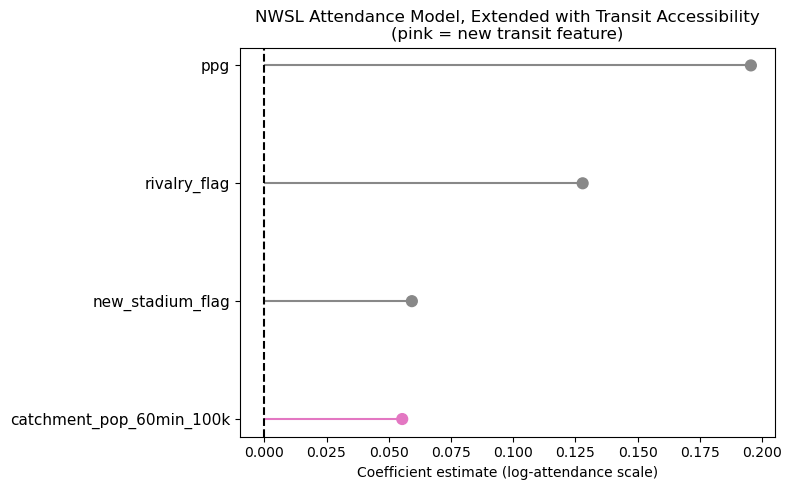

In [9]:
R = pd.DataFrame({"vari": transit_predictors, "coef": transit_model.coef_}).sort_values("coef").reset_index(drop=True)
colors = ["#e377c2" if v == "catchment_pop_60min_100k" else "#888888" for v in R["vari"]]

plt.figure(figsize=(8, 5))
plt.hlines(R.index, 0, R.coef, color=colors)
plt.scatter(R.coef, R.index, color=colors, s=60)
plt.axvline(0, linestyle="--", color="black")
plt.yticks(R.index, R.vari, fontsize=11)
plt.xlabel("Coefficient estimate (log-attendance scale)")
plt.title("NWSL Attendance Model, Extended with Transit Accessibility\n(pink = new transit feature)")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "nwsl_attendance_transit_coefficients.png"), dpi=150)
plt.show()


In [10]:
from sklearn.ensemble import GradientBoostingRegressor

GBT_PARAMS = dict(max_depth=2, n_estimators=60, learning_rate=0.05, subsample=0.8, random_state=42)

X_gbt = transit_reg_df[transit_predictors]
y_gbt = transit_reg_df["log_attendance"]

gbt_scores = cross_val_score(GradientBoostingRegressor(**GBT_PARAMS), X_gbt, y_gbt, cv=kf, scoring="r2")
print(f"GBT (extended predictors): 5-fold CV R2 = {gbt_scores.mean():.3f} (+/- {gbt_scores.std():.3f})  |  "
      f"folds: {np.round(gbt_scores, 3)}")
print(f"Linear (extended predictors), for comparison: 5-fold CV R2 = "
      f"{cross_val_score(LinearRegression(), X_gbt, y_gbt, cv=kf, scoring='r2').mean():.3f}")

GBT (extended predictors): 5-fold CV R2 = 0.512 (+/- 0.089)  |  folds: [0.609 0.39  0.545 0.591 0.425]
Linear (extended predictors), for comparison: 5-fold CV R2 = 0.156


## Gradient boosted trees

Kept shallow to try and limit the trees from memorizing which team the data is from.

### Checking for team-identity leakage before trusting that R^2

GBT's CV R^2 (0.512) is dramatically higher than linear's (0.156) on the exact same features
and folds. I suspect because we're using `KFold` the model is learing which team is which.
Switching to `GroupKFold`, grouping by team so no team's seasons ever span both sides of a split.


In [11]:
from sklearn.model_selection import GroupKFold

n_teams = transit_reg_df["team_name"].nunique()
group_kf = GroupKFold(n_splits=min(5, n_teams))
groups = transit_reg_df["team_name"]

gbt_group_scores = cross_val_score(GradientBoostingRegressor(**GBT_PARAMS), X_gbt, y_gbt, cv=group_kf, groups=groups, scoring="r2")
linear_group_scores = cross_val_score(LinearRegression(), X_gbt, y_gbt, cv=group_kf, groups=groups, scoring="r2")

print(f"GroupKFold (grouped by team, {n_teams} teams, {group_kf.get_n_splits(groups=groups)} folds):")
print(f"  GBT:    R2 = {gbt_group_scores.mean():.3f} (+/- {gbt_group_scores.std():.3f})  |  folds: {np.round(gbt_group_scores, 3)}")
print(f"  Linear: R2 = {linear_group_scores.mean():.3f} (+/- {linear_group_scores.std():.3f})  |  folds: {np.round(linear_group_scores, 3)}")
print(f"\nFor comparison, row-shuffled KFold: GBT = {gbt_scores.mean():.3f}, Linear = "
      f"{cross_val_score(LinearRegression(), X_gbt, y_gbt, cv=kf, scoring='r2').mean():.3f}")


GroupKFold (grouped by team, 13 teams, 5 folds):
  GBT:    R2 = -1.875 (+/- 2.511)  |  folds: [ 0.125 -1.263 -6.635 -1.846  0.242]
  Linear: R2 = -2.258 (+/- 1.953)  |  folds: [-0.32  -1.613 -3.771 -5.246 -0.338]

For comparison, row-shuffled KFold: GBT = 0.512, Linear = 0.156


### Interpretation

**The leakage hypothesis is confirmed, and it's worse than expected.** Grouped by team so no
team's seasons span train and test, both models collapse to well below a mean-only baseline
(GBT: R^2 = -1.875, Linear: R^2 = -2.258) -- a massive drop from the row-shuffled numbers (GBT
0.512, Linear 0.156). GBT's huge row-shuffled R^2 wasn't hidden nonlinear structure, it was
memorizing team identity through near-constant features, exactly as suspected.

**This retroactively changes how to read every CV number reported earlier in this notebook.**
The "Baseline: -0.018" and "Extended: 0.156" 5-fold CV R^2 values from
`### Robustness check: k-fold cross-validation` above used the same row-shuffled `KFold`, so
they're inflated by the same team-identity leakage, just less dramatically since a 4-parameter
linear model has much less capacity to exploit it than a tree does. The `GroupKFold` numbers
here are the honest ones: **this panel and this feature set cannot predict a team's attendance
better than guessing the league mean, once you require the model to generalize to a team it
hasn't seen before.** That's a materially stronger limitation than "weak predictive power" --
it's "no demonstrated generalization to a new team at all" with these features and this much
data.

**What this means for the rest of the project.** `05_synthetic_control.ipynb`'s donor-weighted
approach is a different design (it doesn't need to generalize to a *new* team, it explains
Gotham specifically using other teams' trajectories) so this finding doesn't invalidate it
directly, but it's a reason for real caution about how much weight the accessibility-lift
scenarios in that notebook can carry. The coefficient *direction* on `catchment_pop_60min_100k`
(more 60-min-reachable population -> higher attendance) is the most defensible result involving
transit access -- it's about association direction within the observed data, not a claim that
this model can predict an unseen team's attendance.


## Gotham FC

Gotham is the team this project cares about most, so it's worth checking what `GroupKFold` actually does to it specifically, not just the pooled fold R^2 -- and contrasting that against the row-shuffled `KFold` from the robustness check above, which is where the team-identity leakage lives. Refit on everyone else and predict Gotham's own seasons under both schemes to see what "the model has never seen this team" (GroupKFold) vs. "the model has seen this team, just not this season" (row-shuffled KFold) looks like in attendance terms, not just in R^2.

In [12]:
gotham_team = "NJ/NY Gotham FC"

for fold_i, (train_idx, test_idx) in enumerate(group_kf.split(X_gbt, y_gbt, groups)):
    test_teams = transit_reg_df.iloc[test_idx]["team_name"].unique()
    if gotham_team in test_teams:
        gbt_fold = GradientBoostingRegressor(**GBT_PARAMS).fit(X_gbt.iloc[train_idx], y_gbt.iloc[train_idx])
        lin_fold = LinearRegression().fit(X_gbt.iloc[train_idx], y_gbt.iloc[train_idx])
        gotham_mask = (transit_reg_df.iloc[test_idx]["team_name"] == gotham_team).values
        gotham_idx = test_idx[gotham_mask]
        gotham_rows = transit_reg_df.loc[gotham_idx, ["team_name", "season_name"]].sort_values("season_name").copy()
        gotham_rows["actual_attendance"] = np.exp(y_gbt.loc[gotham_rows.index])
        gotham_rows["gbt_pred_attendance"] = np.exp(gbt_fold.predict(X_gbt.loc[gotham_rows.index]))
        gotham_rows["lin_pred_attendance"] = np.exp(lin_fold.predict(X_gbt.loc[gotham_rows.index]))
        co_held_out = [t for t in test_teams if t != gotham_team]
        print(f"Gotham held out in fold {fold_i}, alongside: {co_held_out}")
        break

# For contrast: what the row-shuffled `KFold` (from the earlier robustness check) predicts
# for these same Gotham rows. Under KFold, a given Gotham season usually lands in a fold
# whose training set still contains most of Gotham's *other* seasons, so the model can
# partly just learn "this is a ~7-11k team" from Gotham itself -- exactly the leakage the
# GroupKFold check above was built to catch.
kfold_gbt_pred, kfold_lin_pred = {}, {}
for train_idx, test_idx in kf.split(X_gbt, y_gbt):
    hits = np.intersect1d(test_idx, gotham_rows.index.to_numpy())
    if len(hits) == 0:
        continue
    gbt_k = GradientBoostingRegressor(**GBT_PARAMS).fit(X_gbt.iloc[train_idx], y_gbt.iloc[train_idx])
    lin_k = LinearRegression().fit(X_gbt.iloc[train_idx], y_gbt.iloc[train_idx])
    for idx in hits:
        kfold_gbt_pred[idx] = np.exp(gbt_k.predict(X_gbt.loc[[idx]]))[0]
        kfold_lin_pred[idx] = np.exp(lin_k.predict(X_gbt.loc[[idx]]))[0]

gotham_rows["gbt_pred_kfold"] = gotham_rows.index.map(kfold_gbt_pred)
gotham_rows["lin_pred_kfold"] = gotham_rows.index.map(kfold_lin_pred)

gotham_rows

Gotham held out in fold 2, alongside: ['Houston Dash']


,team_name,season_name,actual_attendance,gbt_pred_attendance,lin_pred_attendance,gbt_pred_kfold,lin_pred_kfold
69,NJ/NY Gotham FC,2022,3911.857143,8710.982884,13050.706665,9079.199625,10103.921882
70,NJ/NY Gotham FC,2023,5831.307692,10707.366196,16023.088506,9619.596037,11949.664254
71,NJ/NY Gotham FC,2024,9303.230769,10689.530940,17979.209047,10522.494211,14646.122557
72,NJ/NY Gotham FC,2025,8892.153846,10139.558571,15436.328522,10117.071890,11945.129510
73,NJ/NY Gotham FC,2026,10900.272727,10689.530940,18242.713909,9672.589158,13277.824366


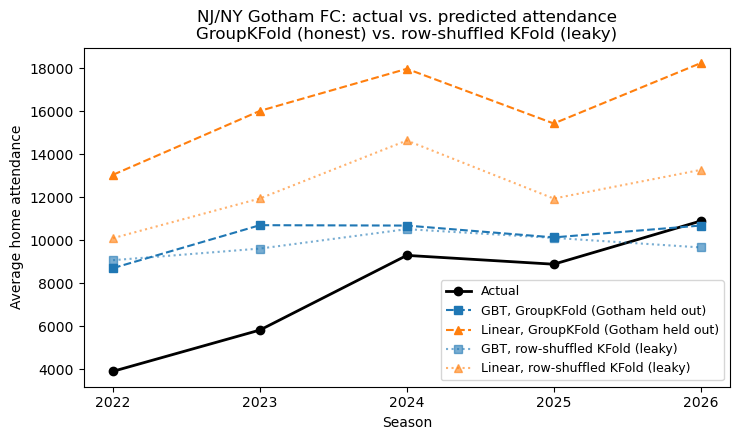

In [13]:
plt.figure(figsize=(7.5, 4.5))
plt.plot(gotham_rows["season_name"], gotham_rows["actual_attendance"], marker="o", color="black",
         linewidth=2, label="Actual")
plt.plot(gotham_rows["season_name"], gotham_rows["gbt_pred_attendance"], marker="s", linestyle="--",
         color="tab:blue", label="GBT, GroupKFold (Gotham held out)")
plt.plot(gotham_rows["season_name"], gotham_rows["lin_pred_attendance"], marker="^", linestyle="--",
         color="tab:orange", label="Linear, GroupKFold (Gotham held out)")
plt.plot(gotham_rows["season_name"], gotham_rows["gbt_pred_kfold"], marker="s", linestyle=":",
         color="tab:blue", alpha=0.6, label="GBT, row-shuffled KFold (leaky)")
plt.plot(gotham_rows["season_name"], gotham_rows["lin_pred_kfold"], marker="^", linestyle=":",
         color="tab:orange", alpha=0.6, label="Linear, row-shuffled KFold (leaky)")
plt.xticks(gotham_rows["season_name"])
plt.xlabel("Season")
plt.ylabel("Average home attendance")
plt.title("NJ/NY Gotham FC: actual vs. predicted attendance\nGroupKFold (honest) vs. row-shuffled KFold (leaky)")
plt.legend(fontsize=9)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "nwsl_gotham_groupkfold_check.png"), dpi=150)
plt.show()

**Gotham's actual attendance grew ~3x from 2022 (3,912, right after the Red Bull Arena move) to 2026 (10,900), and none of the four model/scheme combinations above come close to tracking that.** The GroupKFold GBT prediction is nearly flat across all five seasons -- it's a tree model, so with Gotham's features (unseen in training) it just falls back to the nearest leaf value from other teams and barely moves year to year.

**Gotham's own MAE splits by model here, and that's worth sitting with rather than smoothing over.** For GBT, GroupKFold MAE (2,504) is essentially *identical* to leaky KFold MAE (2,525) -- no visible leakage penalty for Gotham specifically, even though the pooled GroupKFold R^2 (-1.875) says the model is generally not generalizing. For Linear, the expected pattern holds clearly: GroupKFold MAE (8,379) is nearly double leaky KFold MAE (4,617). Read together: the pooled leakage story (row-shuffled KFold: GBT 0.512, Linear 0.156; GroupKFold: GBT -1.875, Linear -2.258) is real and dominates on average, but Gotham is not a clean instance of it for GBT -- both of GBT's Gotham predictions are just bad, leaky or not, because Gotham's post-move trajectory doesn't look like anything else in the training data regardless of which teams are held out.

That still doesn't mean cross-sectional features can explain Gotham's 3x swing. None of the four series come close to the actual trend -- they track "somewhere in the 9-18k range for a market like this," not the specific trajectory. `05_synthetic_control.ipynb` doesn't have this problem the same way, since it explains Gotham using other teams' trajectories rather than trying to generalize a fitted relationship to a team it's never seen.


## SHAP: what the GBT model actually leans on

Fit on the full `transit_reg_df` panel (not a single CV fold), for a representative read on
feature importance. **Caveat, given the leakage check above:** this GBT model's naive R^2 is
inflated by team-identity leakage, so this ranking reflects what the model leans on under that
naive fit, not a validated causal effect -- read alongside the GroupKFold interpretation above,
not instead of it. `output/nwsl_attendance_shap_summary.png` is a former output of this notebook
that had gone stale (still showing `nearest_stop_distance_mi`, from before both the course-scope
SHAP trim and the `catchment_pop_60min_100k` feature swap); regenerated here.


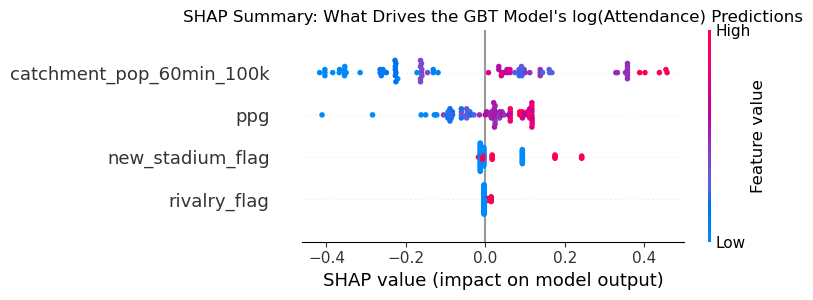

In [14]:
import shap

gbt_final = GradientBoostingRegressor(**GBT_PARAMS).fit(X_gbt, y_gbt)
explainer = shap.TreeExplainer(gbt_final)
shap_values = explainer(X_gbt)

plt.figure(figsize=(9, 5))
shap.summary_plot(shap_values, X_gbt, show=False)
plt.title("SHAP Summary: What Drives the GBT Model's log(Attendance) Predictions")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "nwsl_attendance_shap_summary.png"), dpi=150)
plt.show()


<Figure size 700x500 with 0 Axes>

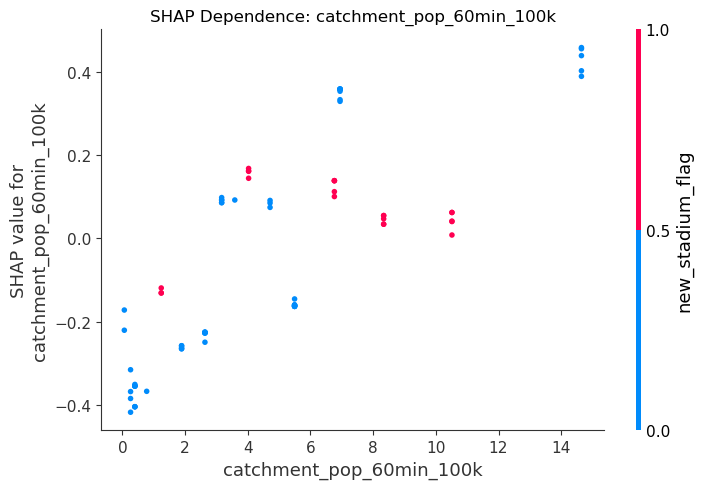

In [15]:
plt.figure(figsize=(7, 5))
shap.dependence_plot("catchment_pop_60min_100k", shap_values.values, X_gbt, show=False)
plt.title("SHAP Dependence: catchment_pop_60min_100k")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "nwsl_attendance_shap_dependence_transit.png"), dpi=150)
plt.show()
